In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import warnings
import re
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [8]:
# Load enriched data
df = pd.read_csv(r'C:\Users\HP\Documents\Projects\predictive-Maintenance\data\processed\week2_enriched.csv')

# Drop non-numeric columns
drop_cols = ['Product ID', 'Type', 'timestamp']
df_model  = df.drop(columns=[c for c in drop_cols 
                              if c in df.columns])

# Features and target
X = df_model.drop(columns=['Machine failure'])
y = df_model['Machine failure']

# Clean column names
def clean_col_name(col):
    col = re.sub(r'[\[\]\(\)\{\}<>]', '', col)
    col = re.sub(r'[^A-Za-z0-9_]', '_', col)
    col = re.sub(r'\+', '', col)
    return col.strip('_')

X.columns = [clean_col_name(c) for c in X.columns]

# Load saved model
with open(r'C:\predictive_maintenance\models\lgbm_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Data and model loaded!")
print("Data shape:", df.shape)
print("Model type:", type(model).__name__)

Data and model loaded!
Data shape: (9991, 83)
Model type: LGBMClassifier


In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE on training data only
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Retrain model with clean column names
model = lgb.LGBMClassifier(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    num_leaves       = 31,
    min_child_samples= 20,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    class_weight     = 'balanced',
    random_state     = 42,
    verbose          = -1
)

model.fit(X_train_sm, y_train_sm)
print("Model retrained successfully!")
print(f"Training rows after SMOTE: {X_train_sm.shape[0]}")

Model retrained successfully!
Training rows after SMOTE: 15442


In [10]:
# Create SHAP explainer
print("Calculating SHAP values - please wait 2-3 minutes...")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification, take failure class (index 1)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print("SHAP values calculated!")
print("Shape of SHAP values:", shap_vals.shape)

Calculating SHAP values - please wait 2-3 minutes...
SHAP values calculated!
Shape of SHAP values: (1999, 82)


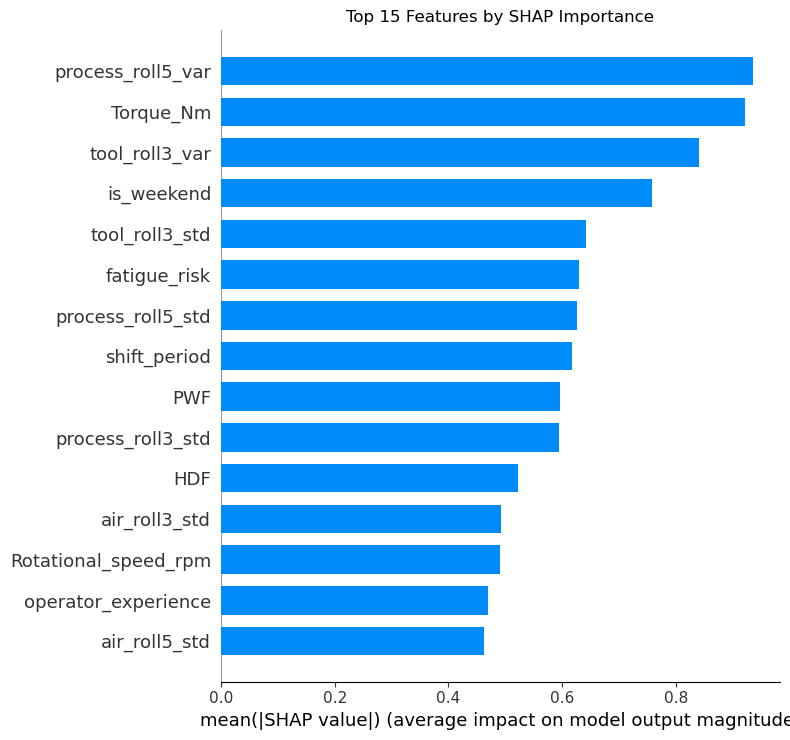

SHAP summary plot saved!


In [11]:
# This shows which features matter most overall
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 Features by SHAP Importance')
plt.tight_layout()
plt.savefig(r'C:\predictive_maintenance\models\shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved!")

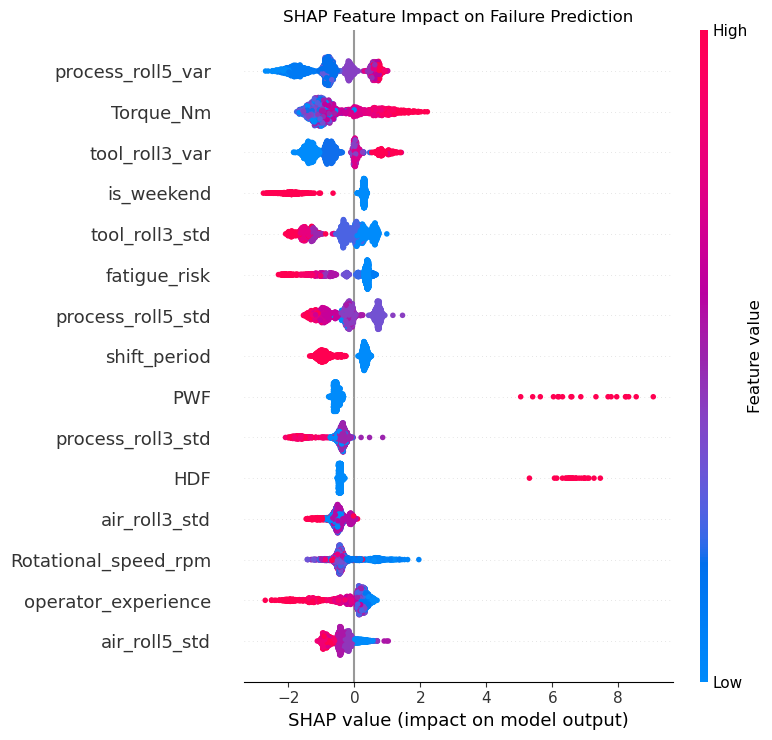

Red = increases failure risk
Blue = decreases failure risk


In [12]:
# This shows HOW each feature affects predictions
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals,
    X_test,
    max_display=15,
    show=False
)
plt.title('SHAP Feature Impact on Failure Prediction')
plt.tight_layout()
plt.show()
print("Red = increases failure risk")
print("Blue = decreases failure risk")

In [13]:
# Pick one machine reading that was predicted as failure
failure_indices = np.where(y_test == 1)[0]
sample_idx      = failure_indices[0]

print(f"Explaining prediction for sample index: {sample_idx}")
print(f"Actual label    : {'Failure' if y_test.iloc[sample_idx]==1 else 'No Failure'}")
print(f"Predicted label : {'Failure' if model.predict(X_test.iloc[[sample_idx]])[0]==1 else 'No Failure'}")
print(f"Failure probability: {model.predict_proba(X_test.iloc[[sample_idx]])[0][1]*100:.1f}%")
print()

# Top reasons for this prediction
sample_shap = shap_vals[sample_idx]
feature_names = X_test.columns.tolist()

shap_df = pd.DataFrame({
    'feature'   : feature_names,
    'shap_value': sample_shap,
    'abs_shap'  : np.abs(sample_shap)
}).sort_values('abs_shap', ascending=False).head(10)

print("Top 10 reasons why this machine is predicted to fail:")
print("=" * 55)
for _, row in shap_df.iterrows():
    direction = "↑ increases risk" if row['shap_value'] > 0 else "↓ decreases risk"
    print(f"  {row['feature']:<35} {direction}")

Explaining prediction for sample index: 78
Actual label    : Failure
Predicted label : Failure
Failure probability: 99.8%

Top 10 reasons why this machine is predicted to fail:
  HDF                                 ↑ increases risk
  Rotational_speed_rpm                ↑ increases risk
  temp_difference                     ↑ increases risk
  tool_roll3_var                      ↓ decreases risk
  process_roll5_var                   ↓ decreases risk
  rotational_lag2                     ↓ decreases risk
  shift_period                        ↓ decreases risk
  Torque_Nm                           ↓ decreases risk
  air_roll10_var                      ↓ decreases risk
  PWF                                 ↓ decreases risk


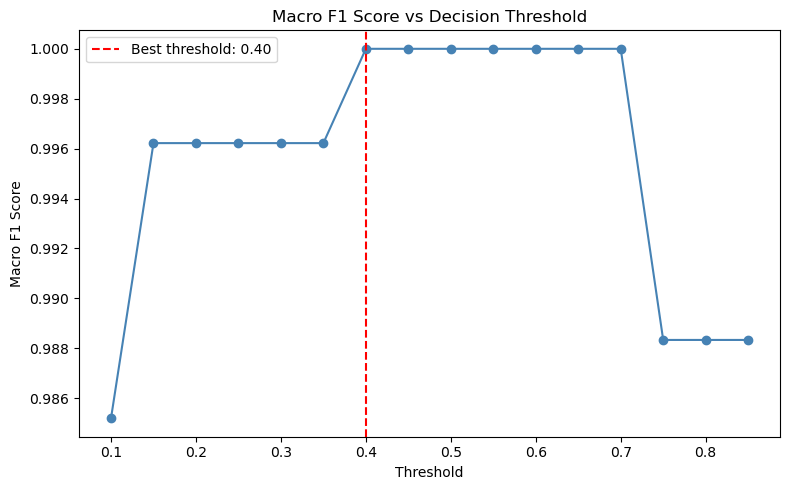

Best threshold : 0.40
Best Macro F1  : 1.0000


In [14]:
thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores  = []
y_proba    = model.predict_proba(X_test)[:, 1]

for thresh in thresholds:
    y_pred_thresh = (y_proba >= thresh).astype(int)
    score = f1_score(y_test, y_pred_thresh, average='macro')
    f1_scores.append(score)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, marker='o', color='steelblue')
plt.axvline(x=best_threshold, color='red', 
            linestyle='--', label=f'Best threshold: {best_threshold:.2f}')
plt.title('Macro F1 Score vs Decision Threshold')
plt.xlabel('Threshold')
plt.ylabel('Macro F1 Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best threshold : {best_threshold:.2f}")
print(f"Best Macro F1  : {best_f1:.4f}")